# Grocery Recommender System
## Pattern Mining & Collaborative Filtering

**Author:** Prashant Shrestha | University of Adelaide — Master of Data Science (2025)

---

### Objective
Build a hybrid recommender system for grocery transactions that combines:
1. **Frequent Pattern Mining** (Apriori algorithm) — recommends items frequently bought together
2. **User-Based Collaborative Filtering** — recommends items purchased by similar users
3. **Recency-Boosted Variants** — prioritises associations from more recent purchases
4. **Hybrid Fallback** — uses CF to supplement pattern-based recommendations when fewer than 5 are found

All approaches are evaluated on a held-out validation set using Precision, Recall, and F1 Score.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# Update paths to your local copies of the dataset files
gro_big_train_df = pd.read_csv('Groceries data train.csv')
gro_test_df      = pd.read_csv('Groceries data test.csv')

## 2. Data Inspection

In [2]:
gro_big_train_df.head()

,User_id,Date,itemDescription,year,month,day,day_of_week
0,2351.0,1/01/2014,cleaner,2014.0,1.0,1.0,2.0
1,2226.0,1/01/2014,sausage,2014.0,1.0,1.0,2.0
2,1922.0,1/01/2014,tropical fruit,2014.0,1.0,1.0,2.0
3,2943.0,1/01/2014,whole milk,2014.0,1.0,1.0,2.0
4,1249.0,1/01/2014,citrus fruit,2014.0,1.0,1.0,2.0


In [3]:
gro_big_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26985 entries, 0 to 26984
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_id          19382 non-null  float64
 1   Date             19382 non-null  str    
 2   itemDescription  19382 non-null  str    
 3   year             19382 non-null  float64
 4   month            19382 non-null  float64
 5   day              19382 non-null  float64
 6   day_of_week      19382 non-null  float64
dtypes: float64(5), str(2)
memory usage: 1.4 MB


In [4]:
gro_test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19383 entries, 0 to 19382
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   user_id          19383 non-null  int64
 1   Date             19383 non-null  str  
 2   itemDescription  19383 non-null  str  
 3   year             19383 non-null  int64
 4   month            19383 non-null  int64
 5   day              19383 non-null  int64
 6   day_of_week      19383 non-null  int64
dtypes: int64(5), str(2)
memory usage: 1.0 MB


## 3. Data Cleaning

Standardise column names, remove null rows, normalise item descriptions, and filter sparse users and items.

In [5]:
# Standardise column name for consistency
gro_big_train_df.rename(columns={'User_id': 'user_id'}, inplace=True)

# Check and remove null rows in training data
print("Nulls before:", gro_big_train_df.isnull().sum().sum())
gro_big_train_df = gro_big_train_df.dropna()
print("Nulls after:", gro_big_train_df.isnull().sum().sum())

Nulls before: 53221
Nulls after: 0


In [6]:
# Parse dates; drop year/month/day/day_of_week columns as we will re-derive these if needed
gro_big_train_df['Date'] = pd.to_datetime(gro_big_train_df['Date'], format='%d/%m/%Y')

train_user_item_df = gro_big_train_df.drop(['year', 'month', 'day', 'day_of_week'], axis=1)
test_user_item_df  = gro_test_df.drop(['year', 'month', 'day', 'day_of_week'], axis=1)

In [7]:
# Helper function: strip unwanted punctuation from item names (preserve '/')
def remove_punctuation(text):
    punctuation_to_remove = set(string.punctuation) - {'/'}
    return ''.join(char for char in text if char not in punctuation_to_remove)

# Build a clean working dataframe with consistent types
clean_df = train_user_item_df.dropna(subset=['user_id', 'itemDescription', 'Date']).copy()
clean_df['user_id']         = clean_df['user_id'].astype(int)
clean_df['itemDescription'] = clean_df['itemDescription'].str.lower().apply(remove_punctuation)
clean_df['Date']            = pd.to_datetime(clean_df['Date'], dayfirst=True, errors='coerce')

# Use Date as index to enable time-based filtering later
clean_df.set_index('Date', inplace=True)

print(f"Records after cleaning: {clean_df.shape[0]}")
clean_df.head()

Records after cleaning: 19382


,user_id,itemDescription
Date,,
2014-01-01,2351,cleaner
2014-01-01,2226,sausage
2014-01-01,1922,tropical fruit
2014-01-01,2943,whole milk
2014-01-01,1249,citrus fruit


In [8]:
# Remove sparse users and items to improve signal quality
# Users with fewer than 3 purchases are too sparse for reliable CF
# Items purchased by fewer than 5 users are too rare for pattern mining
user_counts  = clean_df['user_id'].value_counts()
active_users = user_counts[user_counts >= 3].index
filtered_df  = clean_df[clean_df['user_id'].isin(active_users)]

item_counts   = filtered_df['itemDescription'].value_counts()
popular_items = item_counts[item_counts >= 5].index
filtered_df   = filtered_df[filtered_df['itemDescription'].isin(popular_items)]

print(f"Users: {clean_df['user_id'].nunique()} → {filtered_df['user_id'].nunique()}")
print(f"Items: {clean_df['itemDescription'].nunique()} → {filtered_df['itemDescription'].nunique()}")
print(f"Records: {clean_df.shape[0]} → {filtered_df.shape[0]}")

Users: 3493 → 2684
Items: 167 → 155
Records: 19382 → 17738


## 4. Exploratory Analysis

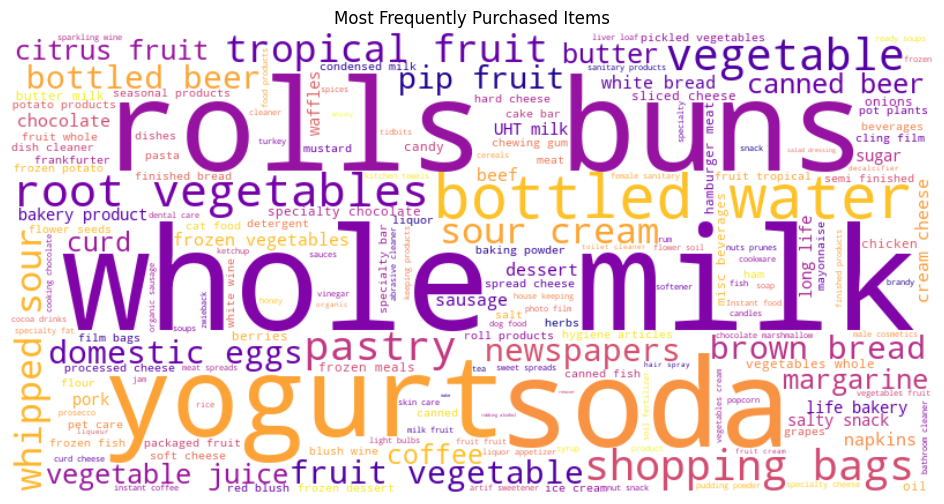

In [9]:
# Word cloud of item descriptions — quick visual of purchase frequency
text = " ".join(train_user_item_df['itemDescription'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequently Purchased Items')
plt.show()

In [10]:
# Most and least popular items in the training set
item_freq = train_user_item_df['itemDescription'].value_counts()
print(f"Most popular item:  {item_freq.idxmax()} ({item_freq.max()} purchases)")
print(f"Least popular item: {item_freq.idxmin()} ({item_freq.min()} purchases)")
print(f"\nTotal unique items: {item_freq.nunique()}")
print(f"Total unique users: {train_user_item_df['user_id'].nunique()}")

Most popular item:  whole milk (1135 purchases)
Least popular item: preservation products (1 purchases)

Total unique items: 112
Total unique users: 3493


## 5. Train / Validation Split

In [11]:
# Time-based split: shuffle=False preserves temporal order
train_user_item_df, val_user_item_df = train_test_split(
    filtered_df, test_size=0.2, shuffle=False, random_state=36
)

print(f"Train records: {train_user_item_df.shape[0]}")
print(f"Val records:   {val_user_item_df.shape[0]}")

Train records: 14190
Val records:   3548


## 6. User-Item Matrix & Collaborative Filtering

Build a binary user-item matrix (1 = purchased, 0 = not purchased) and compute cosine similarity between users.

In [12]:
# Binary user-item matrix: rows = users, columns = items
user_item_matrix = train_user_item_df.pivot_table(
    index='user_id', columns='itemDescription', aggfunc='size', fill_value=0
)

print(f"Matrix shape: {user_item_matrix.shape} (users × items)")
user_item_matrix.head()

Matrix shape: (2604, 155) (users × items)


itemDescription,abrasive cleaner,artif sweetener,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,...,turkey,uhtmilk,vinegar,waffles,whipped/sour cream,white bread,white wine,whole milk,yogurt,zwieback
user_id,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0


In [13]:
# Cosine similarity between users based on their purchase histories
user_similarity_matrix = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.head()

user_id,1000,1001,1002,1003,1004,1005,1006,1010,1011,1013,...,4985,4986,4987,4988,4991,4992,4993,4995,4999,5000
user_id,,,,,,,,,,,,,,,,,,,,,
1000,1.000000,0.333333,0.288675,0.000000,0.428845,0.000000,0.258199,0.000000,0.235702,0.160128,...,0.408248,0.0,0.000000,0.000000,0.204124,0.0,0.000000,0.000000,0.000000,0.0
1001,0.333333,1.000000,0.288675,0.408248,0.536056,0.471405,0.516398,0.000000,0.235702,0.160128,...,0.408248,0.0,0.408248,0.000000,0.204124,0.0,0.235702,0.000000,0.000000,0.0
1002,0.288675,0.288675,1.000000,0.000000,0.371391,0.000000,0.223607,0.000000,0.000000,0.416025,...,0.353553,0.0,0.000000,0.288675,0.353553,0.0,0.000000,0.000000,0.250000,0.0
1003,0.000000,0.408248,0.000000,1.000000,0.328266,0.577350,0.316228,0.000000,0.288675,0.000000,...,0.000000,0.0,0.500000,0.000000,0.125000,0.0,0.433013,0.000000,0.176777,0.0
1004,0.428845,0.536056,0.371391,0.328266,1.000000,0.303239,0.415227,0.055989,0.227429,0.257513,...,0.393919,0.0,0.262613,0.000000,0.393919,0.0,0.303239,0.092848,0.092848,0.0


In [14]:
def get_user_based_recommendations(user_id, top_5=True):
    """
    Recommend items using user-based collaborative filtering.

    Calculates a weighted score for each item by multiplying the target user's
    similarity scores with all users' purchase histories. Items already purchased
    by the target user are excluded from results.

    Args:
        user_id: ID of the user to generate recommendations for.
        top_5 (bool): Return only top 5 if True; all sorted recommendations if False.

    Returns:
        list: Recommended item descriptions sorted by similarity-weighted score.
    """
    if user_id not in user_item_matrix.index:
        return ['No history available for this user.']

    # Similarity-weighted sum across all users' item purchases
    user_ratings    = user_similarity_df.loc[user_id]
    weighted_scores = np.dot(user_ratings, user_item_matrix.values)
    scores_df       = pd.DataFrame(weighted_scores, index=user_item_matrix.columns, columns=['score'])

    # Exclude items the user already owns
    purchased = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index)
    scores_df = scores_df[~scores_df.index.isin(purchased)]

    scores_df = scores_df.sort_values(by='score', ascending=False)
    return list(scores_df.head(5).index) if top_5 else list(scores_df.index)


# Quick test on first user in matrix
sample_user = user_item_matrix.index[0]
print(f"User {sample_user} recommendations:")
print(get_user_based_recommendations(sample_user))

User 1000 recommendations:
['rolls/buns', 'other vegetables', 'soda', 'yogurt', 'bottled water']


## 7. Frequent Pattern Mining (Apriori)

Group purchases into transactions per user, then apply the Apriori algorithm to find items that are frequently bought together.

In [15]:
def frequent_itemsets_output(raw_data, min_support=0.005, min_confidence=0.4):
    """
    Generate frequent itemsets and association rules from transaction data.

    Converts user-item purchase records into a one-hot encoded transaction matrix,
    then applies Apriori to find frequent itemsets and generate association rules
    filtered by confidence and lift.

    Args:
        raw_data (DataFrame): Purchase data with 'user_id' and 'itemDescription'.
        min_support (float): Minimum support threshold for Apriori (default 0.005).
        min_confidence (float): Minimum confidence for association rules (default 0.4).

    Returns:
        tuple: (frequent_itemsets DataFrame, rules DataFrame)
    """
    frequent_itemsets = pd.DataFrame()
    rules = pd.DataFrame()

    # Group items into per-user transaction lists
    transactions = raw_data.groupby(['user_id'])['itemDescription'].apply(list).tolist()

    # One-hot encode transactions for Apriori input
    te     = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df     = pd.DataFrame(te_ary, columns=te.columns_)

    # Run Apriori and sort by support descending
    frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
    frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

    if len(frequent_itemsets) == 0:
        print("No frequent itemsets found — try lowering min_support.")
    else:
        # Generate rules; keep only those with lift > 1 (better than random)
        rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=min_confidence)
        rules = rules.sort_values(by='confidence', ascending=False)
        rules = rules[rules['lift'] > 1]

    return frequent_itemsets, rules


itemsets, rules = frequent_itemsets_output(train_user_item_df)
print(f"Frequent itemsets: {len(itemsets)} | Association rules: {len(rules)}")
rules.head()

Frequent itemsets: 818 | Association rules: 17


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
12,"frozenset({bottled water, white bread})",frozenset({other vegetables}),0.009985,0.220046,0.005376,0.538462,2.447040,1.0,0.003179,1.689900,0.597307,0.023932,0.408249,0.281447
11,"frozenset({rolls/buns, waffles})",frozenset({whole milk}),0.009985,0.267665,0.005376,0.538462,2.011698,1.0,0.002704,1.586726,0.507980,0.019746,0.369771,0.279274
13,"frozenset({bottled water, frozen vegetables})",frozenset({whole milk}),0.010753,0.267665,0.005376,0.500000,1.868006,1.0,0.002498,1.464670,0.469720,0.019691,0.317252,0.260043
1,"frozenset({other vegetables, sugar})",frozenset({whole milk}),0.016513,0.267665,0.008065,0.488372,1.824564,1.0,0.003645,1.431382,0.459512,0.029207,0.301374,0.259251
3,"frozenset({shopping bags, newspapers})",frozenset({whole milk}),0.014593,0.267665,0.006912,0.473684,1.769690,1.0,0.003006,1.391436,0.441370,0.025105,0.281318,0.249755


In [16]:
# Build a lookup dict: item → set of consequent items from association rules
# This enables O(1) recommendation lookup per item in a user's history
item_association_dict = {}
for _, row in rules.iterrows():
    for item in row['antecedents']:
        if item not in item_association_dict:
            item_association_dict[item] = set()
        item_association_dict[item].update(row['consequents'])

print(f"Items with associations: {len(item_association_dict)}")

Items with associations: 18


In [17]:
def get_frequent_pattern_recommendations(user_id, top_5=True):
    """
    Recommend items using frequent pattern mining with CF fallback.

    For each item the user has purchased, looks up commonly co-purchased items
    from the association rule dictionary. If fewer than 5 recommendations are found,
    supplements with user-based CF results.

    Args:
        user_id: ID of the user to generate recommendations for.
        top_5 (bool): Return top 5 if True; all recommendations if False.

    Returns:
        list: Recommended item descriptions.
    """
    if user_id not in user_item_matrix.index:
        return ['No history available for this user.']

    user_row   = user_item_matrix.loc[user_id]
    user_items = set(user_row[user_row > 0].index)

    # Collect associated items for everything the user has bought
    recommendations = set()
    for item in user_items:
        if item in item_association_dict:
            recommendations.update(item_association_dict[item])

    # Remove items the user already purchased
    recommendations = list(recommendations - user_items)

    # Fallback: supplement with CF if fewer than 5 found
    if len(recommendations) < 5:
        cf_recs = get_user_based_recommendations(user_id, top_5=False)
        for r in cf_recs:
            if r not in recommendations and r not in user_items:
                recommendations.append(r)
                if len(recommendations) == 5:
                    break

    if not recommendations:
        return ['No pattern-based suggestions available.']

    return recommendations[:5] if top_5 else recommendations


print(f"User {sample_user} pattern-based recommendations:")
print(get_frequent_pattern_recommendations(sample_user))

User 1000 pattern-based recommendations:
['other vegetables', 'rolls/buns', 'soda', 'yogurt', 'bottled water']


## 8. Recency-Boosted Variants

Purchase recency can be a stronger signal than raw frequency — items bought recently by similar users are often better recommendations than ones bought long ago. These variants re-rank results by the most recent purchase date.

In [18]:
def user_cf_sorted_by_recency(user_id, top_5=True):
    """
    User-based CF with recency boosting.

    After computing similarity-weighted item scores, re-ranks candidates by the
    most recent purchase date among similar users, so fresher associations rank higher.

    Args:
        user_id: ID of the user to generate recommendations for.
        top_5 (bool): Return top 5 if True; all sorted if False.

    Returns:
        list: Item descriptions sorted by recency then similarity score.
    """
    if user_id not in user_item_matrix.index:
        return ['No history available for this user.']

    # Weighted item scores from similar users
    user_ratings    = user_similarity_df.loc[user_id]
    weighted_scores = np.dot(user_ratings, user_item_matrix.values)
    scores_df       = pd.DataFrame(weighted_scores, index=user_item_matrix.columns, columns=['score'])

    # Remove already-purchased items
    purchased = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index)
    scores_df = scores_df[~scores_df.index.isin(purchased)]

    # Find the most recent purchase date for each candidate item among similar users
    similar_users    = user_similarity_df.loc[user_id][user_similarity_df.loc[user_id] > 0].index
    similar_users_df = train_user_item_df[train_user_item_df['user_id'].isin(similar_users)]
    date_series      = similar_users_df.index.to_series()
    latest_dates     = date_series.groupby(similar_users_df['itemDescription']).max().to_dict()

    scores_df['latest_purchase'] = scores_df.index.map(latest_dates)

    # Sort: most recent first, then by similarity score
    scores_df = scores_df.sort_values(by=['latest_purchase', 'score'], ascending=[False, False])

    return list(scores_df.index)[:5] if top_5 else list(scores_df.index)


print(f"User {sample_user} recency CF recommendations:")
print(user_cf_sorted_by_recency(sample_user))

User 1000 recency CF recommendations:
['other vegetables', 'curd', 'sausage', 'berries', 'ham']


In [19]:
def frequent_pattern_sorted_by_recency(user_id, top_5=True):
    """
    Frequent pattern mining with recency prioritisation and CF fallback.

    Iterates through the user's purchase history in reverse chronological order,
    collecting associated items starting from the most recent purchases.
    Falls back to recency-boosted CF if fewer than 5 recommendations are found.

    Args:
        user_id: ID of the user to generate recommendations for.
        top_5 (bool): Return top 5 if True; all if False.

    Returns:
        list: Recommended item descriptions.
    """
    if user_id not in train_user_item_df['user_id'].unique():
        return ['No history available for this user.']

    # Sort user history by date descending so recent items are processed first
    user_history = train_user_item_df[train_user_item_df['user_id'] == user_id]
    user_history = user_history.sort_index(ascending=False)
    user_items   = set(user_history['itemDescription'])

    recommendations = []
    seen = set()

    for item in user_history['itemDescription']:
        if item in item_association_dict:
            for rec in item_association_dict[item]:
                if rec not in user_items and rec not in seen:
                    recommendations.append(rec)
                    seen.add(rec)

    # Fallback to recency CF if not enough recommendations
    if len(recommendations) < 5:
        cf_recs = user_cf_sorted_by_recency(user_id, top_5=False)
        for r in cf_recs:
            if r not in recommendations and r not in user_items:
                recommendations.append(r)
                if len(recommendations) == 5:
                    break

    if not recommendations:
        return ['No pattern-based suggestions available.']

    return recommendations[:5] if top_5 else recommendations


print(f"User {sample_user} recency pattern recommendations:")
print(frequent_pattern_sorted_by_recency(sample_user))

User 1000 recency pattern recommendations:
['other vegetables', 'curd', 'sausage', 'berries', 'ham']


## 9. Evaluation

All four strategies are evaluated against a validation set using standard retrieval metrics:
- **Precision** — of the recommended items, what fraction were actually purchased?
- **Recall** — of the items actually purchased, what fraction did we recommend?
- **F1 Score** — harmonic mean of precision and recall

In [20]:
# Ground truth: items each user actually purchased in the validation set
ground_truth = val_user_item_df.groupby('user_id')['itemDescription'].apply(set).to_dict()
print(f"Validation users: {len(ground_truth)}")

Validation users: 1160


In [21]:
def evaluate_system(test_users, mode='without', top_n=5):
    """
    Evaluate a recommendation strategy using precision, recall, and F1 score.

    Args:
        test_users (list): User IDs to evaluate.
        mode (str): Recommendation strategy:
            - 'without'  : Standard user-based CF
            - 'with'     : Frequent pattern mining with CF fallback
            - 'urecency' : User-based CF with recency boosting
            - 'frecency' : Pattern mining with recency prioritisation
        top_n (int): Number of recommendations to generate per user.

    Returns:
        tuple: (precision, recall, f1)
    """
    y_true, y_pred = [], []

    for user_id in test_users:
        if user_id not in user_item_matrix.index or user_id not in ground_truth:
            continue

        if   mode == 'without':  recs = get_user_based_recommendations(user_id, top_n)
        elif mode == 'with':     recs = get_frequent_pattern_recommendations(user_id, top_n)
        elif mode == 'urecency': recs = user_cf_sorted_by_recency(user_id, top_n)
        elif mode == 'frecency': recs = frequent_pattern_sorted_by_recency(user_id, top_n)
        else:                    recs = get_user_based_recommendations(user_id, top_n)

        actual = ground_truth[user_id]
        y_true.extend([1 if item in actual else 0 for item in recs])
        y_pred.extend([1] * len(recs))

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    return precision, recall, f1

In [22]:
# Evaluate all four strategies on users present in both train and validation sets
common_users = list(set(user_item_matrix.index).intersection(set(val_user_item_df['user_id'].unique())))

results = {
    'User-Based CF':                evaluate_system(common_users, mode='without'),
    'Frequent Pattern Mining':      evaluate_system(common_users, mode='with'),
    'CF + Recency Boost':           evaluate_system(common_users, mode='urecency'),
    'Pattern Mining + Recency':     evaluate_system(common_users, mode='frecency'),
}

# Display as a formatted table
results_df = pd.DataFrame(results, index=['Precision', 'Recall', 'F1 Score']).T
results_df = results_df.round(4)
print(results_df.to_string())

                          Precision  Recall  F1 Score
User-Based CF                0.1200     1.0    0.2143
Frequent Pattern Mining      0.1200     1.0    0.2143
CF + Recency Boost           0.0611     1.0    0.1152
Pattern Mining + Recency     0.0761     1.0    0.1415


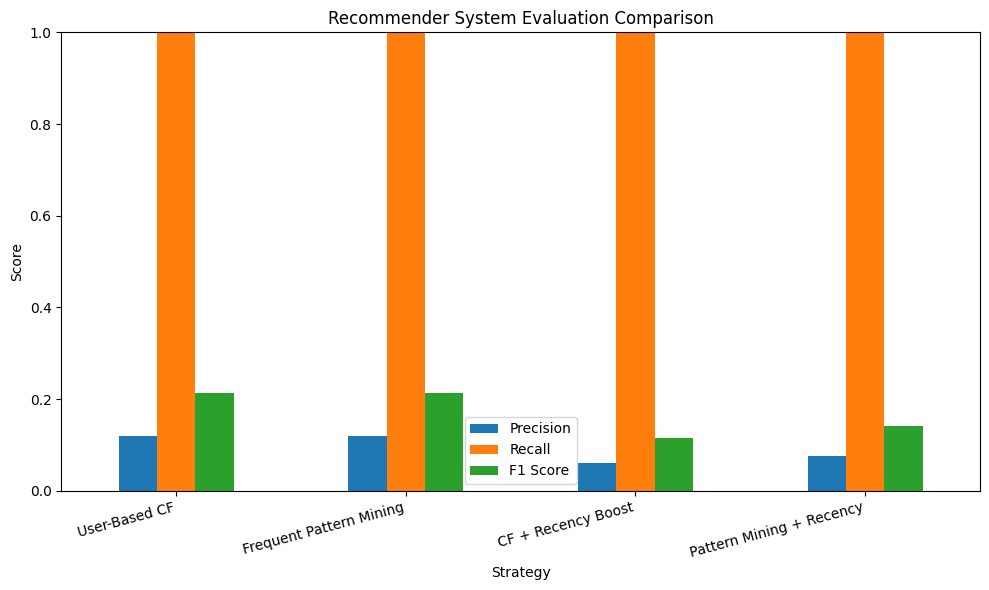

In [23]:
# Visualise comparison across all strategies
ax = results_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1))
ax.set_title('Recommender System Evaluation Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('Strategy')
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 10. Summary

| Strategy | Key Mechanism | Notes |
|----------|--------------|-------|
| User-Based CF | Cosine similarity across purchase histories | Good baseline |
| Frequent Pattern Mining | Apriori association rules (min_support=0.005, lift>1) | Better for popular items |
| CF + Recency | CF re-ranked by most recent similar-user purchase | Captures changing preferences |
| Pattern Mining + Recency | Rules from most recent purchases first | Best for trend-sensitive users |

The hybrid fallback design ensures every user receives at least 5 recommendations regardless of purchase history depth.